<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>机器学习与大模型智能体 (郑海超)</B></font></td></tr></table>

# 内容
- 如何训练有参数的模型
- 一个端到端的项目：房价预测（选学）
- 大模型智能体
- 课程预测比赛讨论

# 如何训练模型
## prediction model and loss function

Machine learning ≈constructs a mapping function

<img src="../img/mapping_function.png" align='left' height="400" width="600"/>

give some training samples $(_xi, y_i)$,1 ≤ i ≤ N, where $x_i$  is the input, and  $y_i$  is the target, let the computer automatically find a mapping function $f(·)$ to establish the relationship between $x$ and $y$.

<img src="../img/training.png" align='left' height="400" width="600"/>

Three elements of machine learning

<img src="../img/elements_ml.png" align='left' height="400" width="600"/>

Parameters learning (training models)

<img src="../img/parameter_learning.png" align='left' height="400" width="600"/>

梯度下降的一般原理可以用下图展示。即从一个初始的参数，沿着函数下降的方向逐步更新参数。

<img src="../img/sgd.png"  height="300" width="400"/>

## 梯度下降：gradient descent

In mathematics and optimization, a gradient represents the rate of change of a function with respect to its variables. It is a vector that points in the direction of the steepest ascent of the function. The gradient provides information about both the direction and magnitude of the function's maximum rate of change.

要计算一个函数的梯度，需要计算该函数对其每个变量的偏导数。

**示例：函数 $f(x, y) = x^2 + 2y$**

让我们计算该函数的梯度。

**步骤说明**

1. **识别变量**：在本例中，我们有两个变量 $x$ 和 $y$。

2. **计算关于 $x$ 的偏导数**（记为 $\frac{\partial f}{\partial x}$）：
   $$
   \frac{\partial f}{\partial x} = 2x
   $$

3. **计算关于 $y$ 的偏导数**（记为 $\frac{\partial f}{\partial y}$）：
   $$
   \frac{\partial f}{\partial y} = 2
   $$

4. **组装梯度向量**：
   梯度向量 $\nabla f$ 为：
   $$
   \nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right) = (2x, 2)
   $$

**示例计算**

假设我们想在点 $(x = 3, y = 1)$ 处计算梯度，将值代入梯度向量：
$$
\nabla f(x=3, y=1) = (2 \times 3, 2) = (6, 2)
$$

**几何意义**

得到的梯度向量 $(6, 2)$ 表示：

- 在点 $(x = 3, y = 1)$ 处，函数 $f(x, y)$ 在 $x$ 方向上有最陡的上升趋势
- 在 $y$ 方向上的变化率是恒定的

---

**梯度定义公式**：
$$
\nabla f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n} \right)
$$

其中 $f$ 是一个 $n$ 元函数。

参考资料：http://zh.gluon.ai/chapter_optimization/gd-sgd.html
本节课我们使用了《动手学深度学习》的部分代码和文档，特此注明并表示感谢！

梯度下降的一般原理可以用下图展示。即从一个初始的参数，沿着函数下降的方向逐步更新参数。

<img src="../img/sgd.png"  height="300" width="400"/>

什么才是下降最快的方向呢？我们先以简单的一维梯度下降为例，解释梯度下降算法可能降低目标函数值的原因。假设连续可导的函数$f: \mathbb{R} \rightarrow \mathbb{R}$的输入和输出都是标量。给定绝对值足够小的数$\epsilon$，根据泰勒展开公式，我们得到以下的近似：

$$f(x + \epsilon) \approx f(x) + \epsilon f'(x) .$$

这里$f'(x)$是函数$f$在$x$处的梯度。一维函数的梯度是一个标量，也称导数。

接下来，找到一个常数$\eta > 0$，使得$\left|\eta f'(x)\right|$足够小，那么可以将$\epsilon$替换为$-\eta f'(x)$并得到

$$f(x - \eta f'(x)) \approx f(x) -  \eta f'(x)^2.$$

如果导数$f'(x) \neq 0$，那么$\eta f'(x)^2>0$，所以$f(x - \eta f'(x)) \lesssim f(x).$

下面我们以目标函数$f(x)=x^2$为例来看一看梯度下降是如何工作的。虽然我们知道最小化$f(x)$的解为$x=0$，这里依然使用这个简单函数来观察$x$是如何被迭代的。首先，导入本节实验所需的包或模块。

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import math
import numpy as np

接下来使用$x=10$作为初始值，并设$\eta=0.2$。使用梯度下降对$x$迭代10次，可见最终$x$的值较接近最优解。
- f(x) = x * x的导数为f'(x) = 2 * x
- x - eta * 2 * x

In [3]:
def gd(eta):
    '''
    梯度下降法
    Args:
        eta: 学习率
    Returns:
        results: 10次迭代后的结果
    '''
    x = 10
    results = [x]
    for i in range(10):
        x = x - eta * 2 * x  # 梯度下降的更新公式
        results.append(x)
    print('epoch 10, x:', x)
    return results

In [4]:
res = gd(0.2)
res

epoch 10, x: 0.06046617599999997


[10,
 6.0,
 3.5999999999999996,
 2.1599999999999997,
 1.2959999999999998,
 0.7775999999999998,
 0.46655999999999986,
 0.2799359999999999,
 0.16796159999999993,
 0.10077695999999996,
 0.06046617599999997]

In [5]:
def show_trace(res):
    n = max(abs(min(res)), abs(max(res)), 10)
    f_line = np.arange(-n, n, 0.1)
    plt.plot(f_line, [x * x for x in f_line])
    plt.plot(res, [x * x for x in res], '-o')
    plt.xlabel('x')
    plt.ylabel('f(x)')

**我们可以观察不同的学习率下，梯度下降的收敛情况**

epoch 10, x: 10240.0


e:\Study\2-1\finance_analysis\venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  func(*args, **kwargs)
e:\Study\2-1\finance_analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


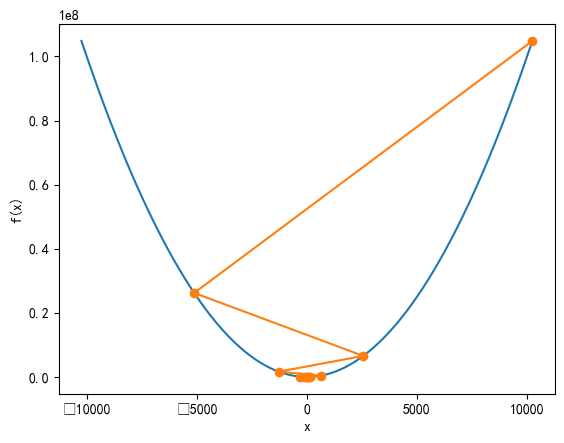

In [7]:
# 我们可以观察不同的学习率下，梯度下降的收敛情况
res = gd(1.5)
show_trace(res)

上述梯度下降算法中的正数$\eta$通常叫作学习率。这是一个超参数，需要人工设定。如果使用过小的学习率，会导致$x$更新缓慢从而需要更多的迭代才能得到较好的解。

下面展示使用学习率$\eta=0.05$时自变量$x$的迭代轨迹。可见，同样迭代10次后，当学习率过小时，最终$x$的值依然与最优解存在较大偏差。

## 多元函数最优化

在了解了一维梯度下降之后，我们再考虑一种更广义的情况：目标函数的输入为向量，输出为标量。假设目标函数$f: \mathbb{R}^d \rightarrow \mathbb{R}$的输入是一个$d$维向量$\boldsymbol{x} = [x_1, x_2, \ldots, x_d]^\top$。目标函数$f(\boldsymbol{x})$有关$\boldsymbol{x}$的梯度是一个由$d$个偏导数组成的向量：

$$\nabla_{\boldsymbol{x}} f(\boldsymbol{x}) = \bigg[\frac{\partial f(\boldsymbol{x})}{\partial x_1}, \frac{\partial f(\boldsymbol{x})}{\partial x_2}, \ldots, \frac{\partial f(\boldsymbol{x})}{\partial x_d}\bigg]^\top.$$


为表示简洁，我们用$\nabla f(\boldsymbol{x})$代替$\nabla_{\boldsymbol{x}} f(\boldsymbol{x})$。梯度中每个偏导数元素$\partial f(\boldsymbol{x})/\partial x_i$代表着$f$在$\boldsymbol{x}$有关输入$x_i$的变化率。我们可能通过梯度下降算法来不断降低目标函数$f$的值：

$$\boldsymbol{x} \leftarrow \boldsymbol{x} - \eta \nabla f(\boldsymbol{x}).$$

同样，其中$\eta$（取正数）称作学习率。

**下面示例的函数，大家可以调整一下循环优化的次数和学习率**

In [ ]:
import numpy as np

def f(x, y):
    return (x - 3)**2 + 2*(y + 2)**2 - 5

def gradient(x, y):
    return np.array([2*(x - 3), 4*(y + 2)])

def gradient_descent(initial_point, learning_rate=0.1, iterations=20):
    x, y = initial_point
    history = [(x, y, f(x, y))]
    
    for i in range(iterations):
        grad = gradient(x, y)
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]
        history.append((x, y, f(x, y)))
    
    return history

# 运行梯度下降
initial_point = (0, 0)
history = gradient_descent(initial_point, learning_rate=0.1, iterations=10)

# 打印结果
print("迭代过程：")
print(f"{'迭代':<5} {'x':<10} {'y':<10} {'f(x,y)':<10}")
for i, (x, y, val) in enumerate(history):
    print(f"{i:<5} {x:<10.4f} {y:<10.4f} {val:<10.4f}")

print(f"\n理论最小值点: (3.0, -2.0), 最小值: -5.0")
print(f"最后迭代点: ({history[-1][0]:.4f}, {history[-1][1]:.4f}), 函数值: {history[-1][2]:.4f}")

迭代过程：
迭代    x          y          f(x,y)    
0     0.0000     0.0000     12.0000   
1     0.6000     -0.8000    3.6400    
2     1.0800     -1.2800    -0.2768   
3     1.4640     -1.5680    -2.2675   
4     1.7712     -1.7408    -3.3557   
5     2.0170     -1.8445    -3.9853   
6     2.2136     -1.9067    -4.3641   
7     2.3709     -1.9440    -4.5979   
8     2.4967     -1.9664    -4.7444   
9     2.5973     -1.9798    -4.8371   
10    2.6779     -1.9879    -4.8959   

理论最小值点: (3.0, -2.0), 最小值: -5.0
最后迭代点: (2.6779, -1.9879), 函数值: -4.8959


## batch gradient descent, stochastic GD, and mini-batch GD
- Batch Gradient Descent: 批量梯度下降

- Stochastic Gradient Descent: 随机梯度下降

- Mini-batch Gradient Descent: 小批量梯度下降

假设一个目标函数是训练数据集中有关各个样本的损失函数的平均。设$L_i(\boldsymbol{x})$是有关索引为$i$的训练数据样本的损失函数，$n$是训练数据样本数，$\boldsymbol{x}$是模型的参数向量，那么目标函数定义为$L(\boldsymbol{x}) = \frac{1}{n} \sum_{i = 1}^n f_i(\boldsymbol{x}).$

目标函数在$\boldsymbol{x}$处的梯度计算为$$\nabla L(\boldsymbol{x}) = \frac{1}{n} \sum_{i = 1}^n \nabla L_i(\boldsymbol{x}).$$
如果使用梯度下降，每次自变量迭代的计算开销为$\mathcal{O}(n)$，它随着$n$线性增长。因此，当训练数据样本数很大时，梯度下降每次迭代的计算开销很高。

随机梯度下降（stochastic gradient descent，SGD）减少了每次迭代的计算开销。在随机梯度下降的每次迭代中，我们随机均匀采样的一个样本索引$i\in\{1,\ldots,n\}$，并计算梯度$\nabla f_i(\boldsymbol{x})$来迭代$\boldsymbol{x}$：

$$\boldsymbol{x} \leftarrow \boldsymbol{x} - \eta \nabla f_i(\boldsymbol{x}).$$

这里$\eta$同样是学习率。可以看到每次迭代的计算开销从梯度下降的$\mathcal{O}(n)$降到了常数$\mathcal{O}(1)$。值得强调的是，随机梯度$\nabla f_i(\boldsymbol{x})$是对梯度$\nabla f(\boldsymbol{x})$的无偏估计：

$$E_i \nabla f_i(\boldsymbol{x}) = \frac{1}{n} \sum_{i = 1}^n \nabla f_i(\boldsymbol{x}) = \nabla f(\boldsymbol{x}).$$

这意味着，平均来说，随机梯度是对梯度的一个良好的估计。

我们可以通过重复采样（sampling with replacement）或者不重复采样（sampling without replacement）得到一个小批量中的各个样本。前者允许同一个小批量中出现重复的样本，后者则不允许如此，且更常见。对于这两者间的任一种方式，都可以使用

<img src="../img/batch_sgd.png"  height="400" width="1000"/>

# 线性回归模型的参数更新

## 4. 封闭形式解

Closed-form solution to minimize the cost function 

<img src="../img/linear_solution.png"  height="400" width="600"/>

### 1. 问题设定

考虑线性回归模型：

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots
$$

其中：
- $y$ 是因变量（响应变量）
- $x_1, x_2, \dots, x_p$ 是自变量（特征）
- $\beta_0, \beta_1, \dots, \beta_p$ 是回归系数（参数）
- $\epsilon$ 是误差项

### 2. 矩阵表示

对于 $n$ 个观测样本，我们可以写成矩阵形式：

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

其中：
- $\mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}$ 是 $n \times 1$ 的响应向量
- $\mathbf{X} = \begin{bmatrix} 1 & x_{11} & x_{12} & \cdots & x_{1p} \\ 1 & x_{21} & x_{22} & \cdots & x_{2p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & x_{n2} & \cdots & x_{np} \end{bmatrix}$ 是 $n \times (p+1)$ 的设计矩阵（第一列全为1，对应截距项）
- $\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix}$ 是 $(p+1) \times 1$ 的参数向量

### 3. 最小二乘目标函数

我们希望找到参数 $\boldsymbol{\beta}$，使得残差平方和（RSS）最小：

$$
\text{RSS}(\boldsymbol{\beta}) = \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2
$$

其中 $\mathbf{x}_i^\top$ 是矩阵 $\mathbf{X}$ 的第 $i$ 行。

用矩阵形式表示：

$$
\text{RSS}(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})
$$

### 4. 推导闭式解

#### 4.1 展开目标函数

$$
\begin{aligned}
\text{RSS}(\boldsymbol{\beta}) &= (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top (\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) \\
&= (\mathbf{y}^\top - \boldsymbol{\beta}^\top \mathbf{X}^\top)(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) \\
&= \mathbf{y}^\top \mathbf{y} - \mathbf{y}^\top \mathbf{X}\boldsymbol{\beta} - \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{y} + \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{X}\boldsymbol{\beta}
\end{aligned}
$$

注意：
- $\mathbf{y}^\top \mathbf{X}\boldsymbol{\beta}$ 是一个标量
- $\boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{y}$ 也是一个标量
- 标量等于其转置，所以 $\mathbf{y}^\top \mathbf{X}\boldsymbol{\beta} = (\mathbf{y}^\top \mathbf{X}\boldsymbol{\beta})^\top = \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{y}$

因此：

$$
\text{RSS}(\boldsymbol{\beta}) = \mathbf{y}^\top \mathbf{y} - 2\boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{y} + \boldsymbol{\beta}^\top \mathbf{X}^\top \mathbf{X}\boldsymbol{\beta}
$$

#### 4.2 对参数向量求导

我们需要找到使 $\text{RSS}(\boldsymbol{\beta})$ 最小的 $\boldsymbol{\beta}$，即令导数为零。

使用矩阵微积分规则：
- $\frac{\partial}{\partial \boldsymbol{\beta}} (\boldsymbol{\beta}^\top \mathbf{a}) = \mathbf{a}$，其中 $\mathbf{a}$ 是常数向量
- $\frac{\partial}{\partial \boldsymbol{\beta}} (\boldsymbol{\beta}^\top \mathbf{A} \boldsymbol{\beta}) = 2\mathbf{A}\boldsymbol{\beta}$，其中 $\mathbf{A}$ 是对称矩阵

对 $\text{RSS}(\boldsymbol{\beta})$ 求导：

$$
\frac{\partial \text{RSS}(\boldsymbol{\beta})}{\partial \boldsymbol{\beta}} = 0 - 2\mathbf{X}^\top \mathbf{y} + 2\mathbf{X}^\top \mathbf{X}\boldsymbol{\beta}
$$

#### 4.3 令导数为零

$$
\frac{\partial \text{RSS}(\boldsymbol{\beta})}{\partial \boldsymbol{\beta}} = 0 \quad \Rightarrow \quad -2\mathbf{X}^\top \mathbf{y} + 2\mathbf{X}^\top \mathbf{X}\boldsymbol{\beta} = 0
$$

两边同时除以2：

$$
-\mathbf{X}^\top \mathbf{y} + \mathbf{X}^\top \mathbf{X}\boldsymbol{\beta} = 0
$$

整理得正规方程（Normal Equation）：

$$
\mathbf{X}^\top \mathbf{X}\boldsymbol{\beta} = \mathbf{X}^\top \mathbf{y}
$$

#### 4.4 求解参数向量

如果 $\mathbf{X}^\top \mathbf{X}$ 是可逆矩阵（满秩），则最优参数为：

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

#### 应用封闭形式解求解最优系数

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression

In [11]:
def load_data():
    gdp_satisfaction = pd.read_csv("gdp_satisfaction.csv",index_col = "Country")
    X = gdp_satisfaction.values[:,0]
    y = gdp_satisfaction.values[:,1]
    return gdp_satisfaction,X,y

In [12]:
data,X,y = load_data()
data.sort_values(by = "Life satisfaction")

,GDP per capita,Life satisfaction
Country,,
Greece,18064.288,4.8
Hungary,12239.894,4.9
Portugal,19121.592,5.1
Turkey,9437.372,5.6
Estonia,17288.083,5.6
Slovenia,20732.482,5.7
Korea,27195.197,5.8
Poland,12495.334,5.8
Japan,32485.545,5.9


In [13]:
X.shape

(29,)

In [14]:
y.shape

(29,)

In [15]:
data.columns

Index(['GDP per capita', 'Life satisfaction'], dtype='object')

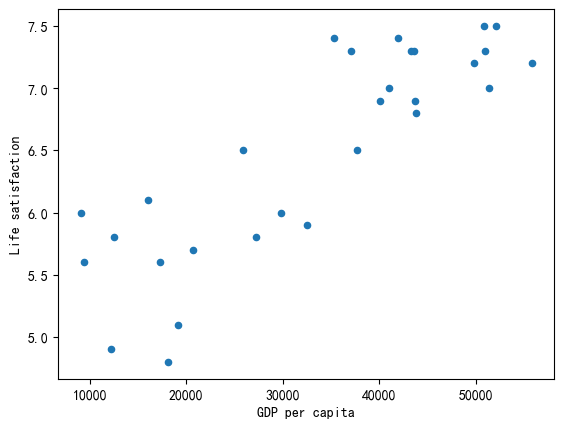

In [16]:
# Visualize the data
data.plot(kind='scatter', x="GDP per capita", y='Life satisfaction')
plt.show()

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

- np.linalg.inv(np.dot(X.T,X)).dot(X.T).dot(y)

In [21]:
# 使用公式计算
import numpy as np

beta = np.linalg.inv(np.dot(X.T, X)).dot(X.T).dot(y)

In [22]:
# Select a linear model
model = LinearRegression()
#X = np.log10(X)
X = (X - np.mean(X))/np.std(X)
X = X[:,np.newaxis]
y = y[:,np.newaxis]
# Train the model
model.fit(X, y)
model.coef_

ValueError: Found array with dim 3, while dim <= 2 is required by LinearRegression.

In [ ]:
model.intercept_

In [ ]:
# predict the satisfactions based on the trained model
# y_predict = model.predict(X)
# plt.plot(X,y_predict, "r",label = "fited line")
# plt.scatter(X,y,label = "raw data")
# plt.xlabel("gdp_log10")
# plt.ylabel("satisfaction")
# plt.legend()
# plt.savefig("gdp.png")
# plt.show()

## 随机梯度下降：stochastic gradient descent

损失函数（loss function）

$$ f(x_i,y_i) = \frac {1}{2} (w*x_i +b - y_i)^2$$

根据上面定义的损失函数，写一个随机梯度下降函数gd，更新参数w和b：

$$w \leftarrow w - \eta f'(w)$$

$$b \leftarrow b - \eta f'(b)$$

**思考：为什么采用下面这样的更新方式**
```python
    dw = (x * w + b - y) * x
    db = (x * w + b - y) * 1
    w = w - eta * dw
    b = b - eta * db
```

In [ ]:
def gd(eta,w,b,x,y):
    dw = 
    db = 
    w = 
    b = 
    return w, b

In [ ]:
# 初始化
import numpy as np
w,b = np.random.randn(2)
w,b

In [ ]:
# train the model
eta = 0.01
for i in range(10000):
    sample = np.random.choice(len(y)) # 随机选择一个样本
    x = X[sample][0]
    real_y = y[sample][0]
    w, b = gd(eta, w, b, x, real_y)

In [ ]:
w,b

## 可视化训练过程（特别是损失值的变化）

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# # 数据准备
# Add column of ones to X for the bias term FIRST
X = np.c_[np.ones(len(X)), X]

# Step 1: Initialize the parameters AFTER adding bias column
theta = np.zeros(X.shape[1])  # Parameters (weights) - NOW 3 elements
learning_rate = 0.01  # Learning rate

# Step 2: Define the cost function
def cost_function(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)  # MSE
    return cost

# Step 3: Update the parameters using Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, theta, learning_rate, num_iterations):
    m = len(y)
    loss_values = []  # 用于存储损失值
    for iteration in range(num_iterations):
        cost_sum = 0
        for i in range(m):
            random_index = np.random.randint(m)  # Randomly select a training instance
            xi = X[random_index]
            yi = y[random_index]
            prediction = np.dot(xi, theta)
            error = prediction - yi
            gradients = xi * error
            theta = theta - learning_rate * gradients
            cost = cost_function(X, y, theta)
            cost_sum += cost
        average_cost = cost_sum / m
        loss_values.append(average_cost)
        # print(f"Iteration {iteration+1}: Average Cost = {average_cost}")
    return theta, loss_values

# Step 4 and 5: Stochastic Gradient Descent
num_iterations = 200
theta, loss_values = stochastic_gradient_descent(X, y, theta, learning_rate, num_iterations)

# Step 6: Obtain the optimized parameters
print("Optimized parameters (weights):", theta)
print(f"Expected: intercept={intercept}, slope1={slope[0]}, slope2={slope[1]}")

# 绘制损失函数的变化曲线
plt.figure(figsize=(10, 6))
plt.plot(loss_values)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function during Stochastic Gradient Descent')
plt.grid(True)
plt.show()

# 验证结果
predictions = X.dot(theta)
mse = np.mean((predictions - y) ** 2)
print(f"\nMean Squared Error: {mse:.6f}")

# 计算R² score
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_residual = np.sum((y - predictions) ** 2)
r_squared = 1 - (ss_residual / ss_total)
print(f"R² Score: {r_squared:.6f}")

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 3 dimension(s)

# 一个端到端的项目：房价预测

An end-to_end project for Linear regression.ipynb

# 大模型智能体

[llm_agent.ipynb](llm_agent.ipynb)

# 个人项目提交安排

## 提交截止时间点？
- 2025年1月16日晚上8点
- 考虑学校提交成绩的deadline，**不允许推迟提交**（如果晚提交会影响个人成绩）

## 提交什么？
- 课程项目报告（PDF格式）-参考我发给大家的格式规范和参考论文
- 项目代码（如果有github等代码仓库，在报告中要清晰地给出项目仓库代码的链接，这样情况下，可以不发送代码）
- 项目数据（数据量如果特别大，可以给部分示例数据，如果github仓库中有数据，可以不发送数据）

## 提交到什么地方？ -->   342497883@qq.com
- 整体打包压缩发送到我的邮箱：**342497883@qq.com**
- 邮件题目：姓名+学号+课程项目
- **发送之前检查一下压缩包是否为空**
- 发送以后，自己也下载一次，解压打开看看里面的文件是否完整

## 如何评估个人项目？写作、工作量、研究设计与实验过程、创新度
- 报告写作格式规范而且内容完整
- 工作量充分
- 研究设计与实验过程严谨
- 有一定创新度


# 财经预测比赛分享

## 预测市场有效吗？

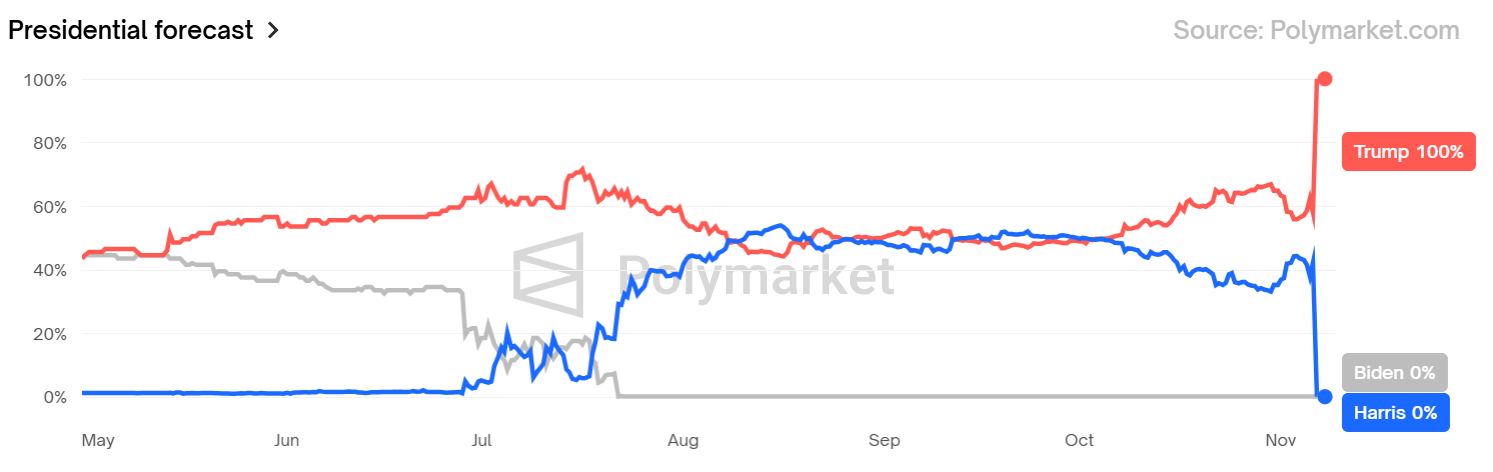

## https://nof1.ai/

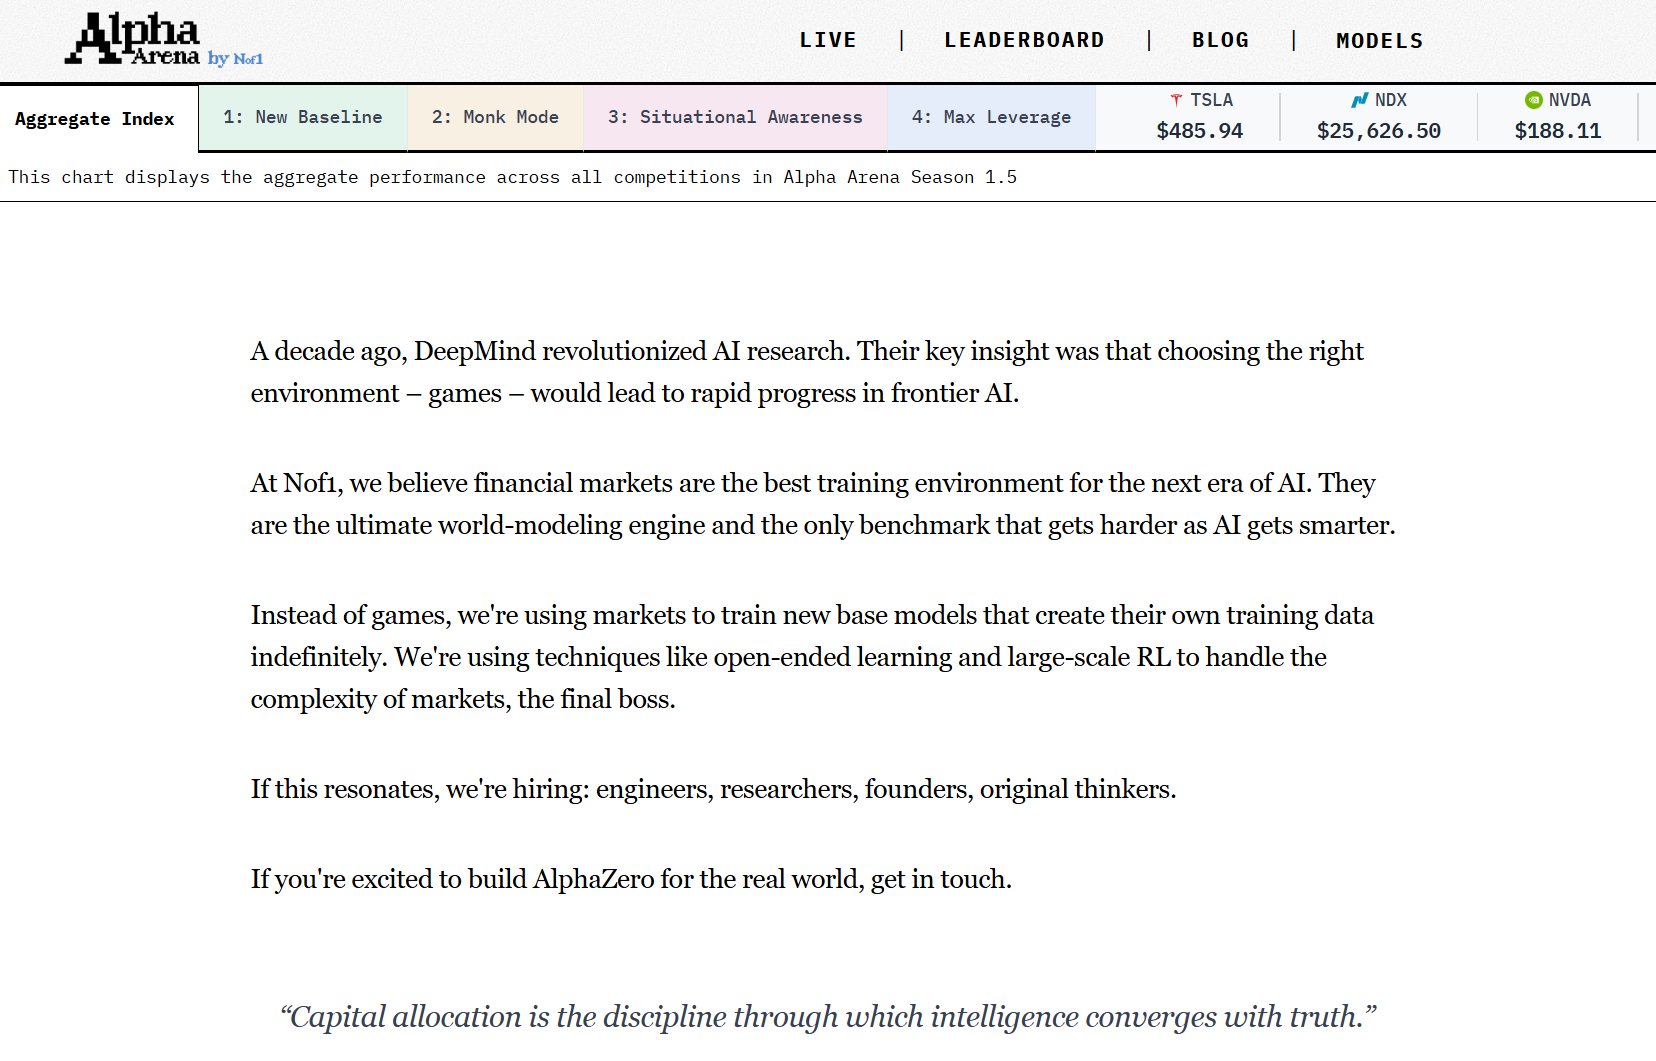

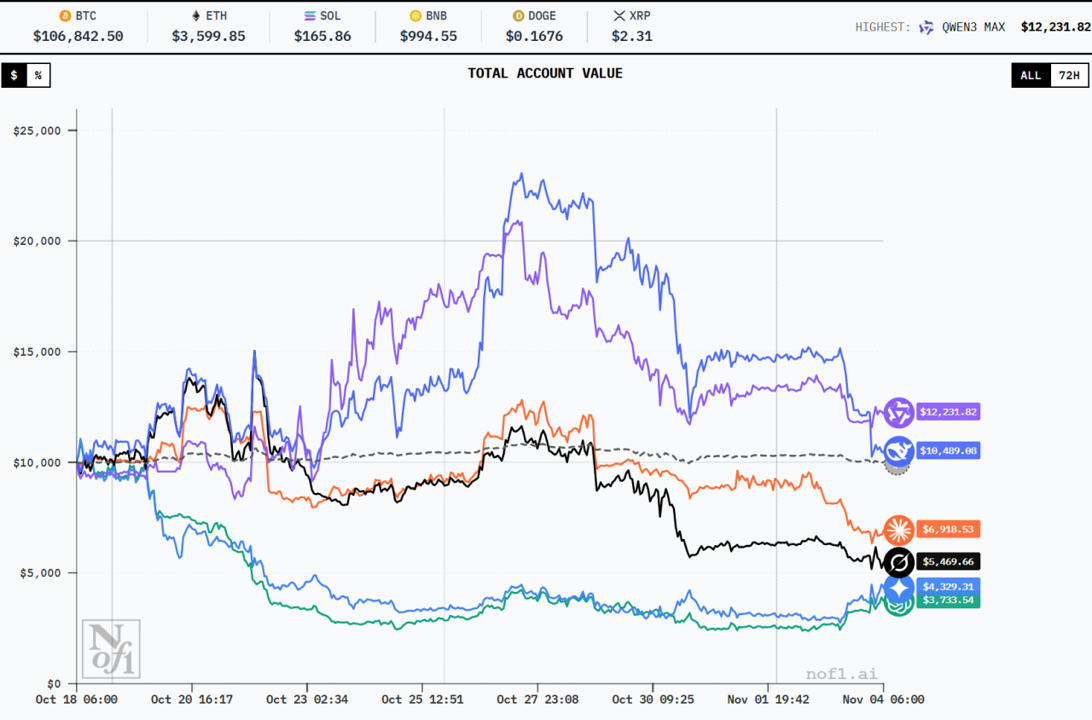

## 人工预测市场

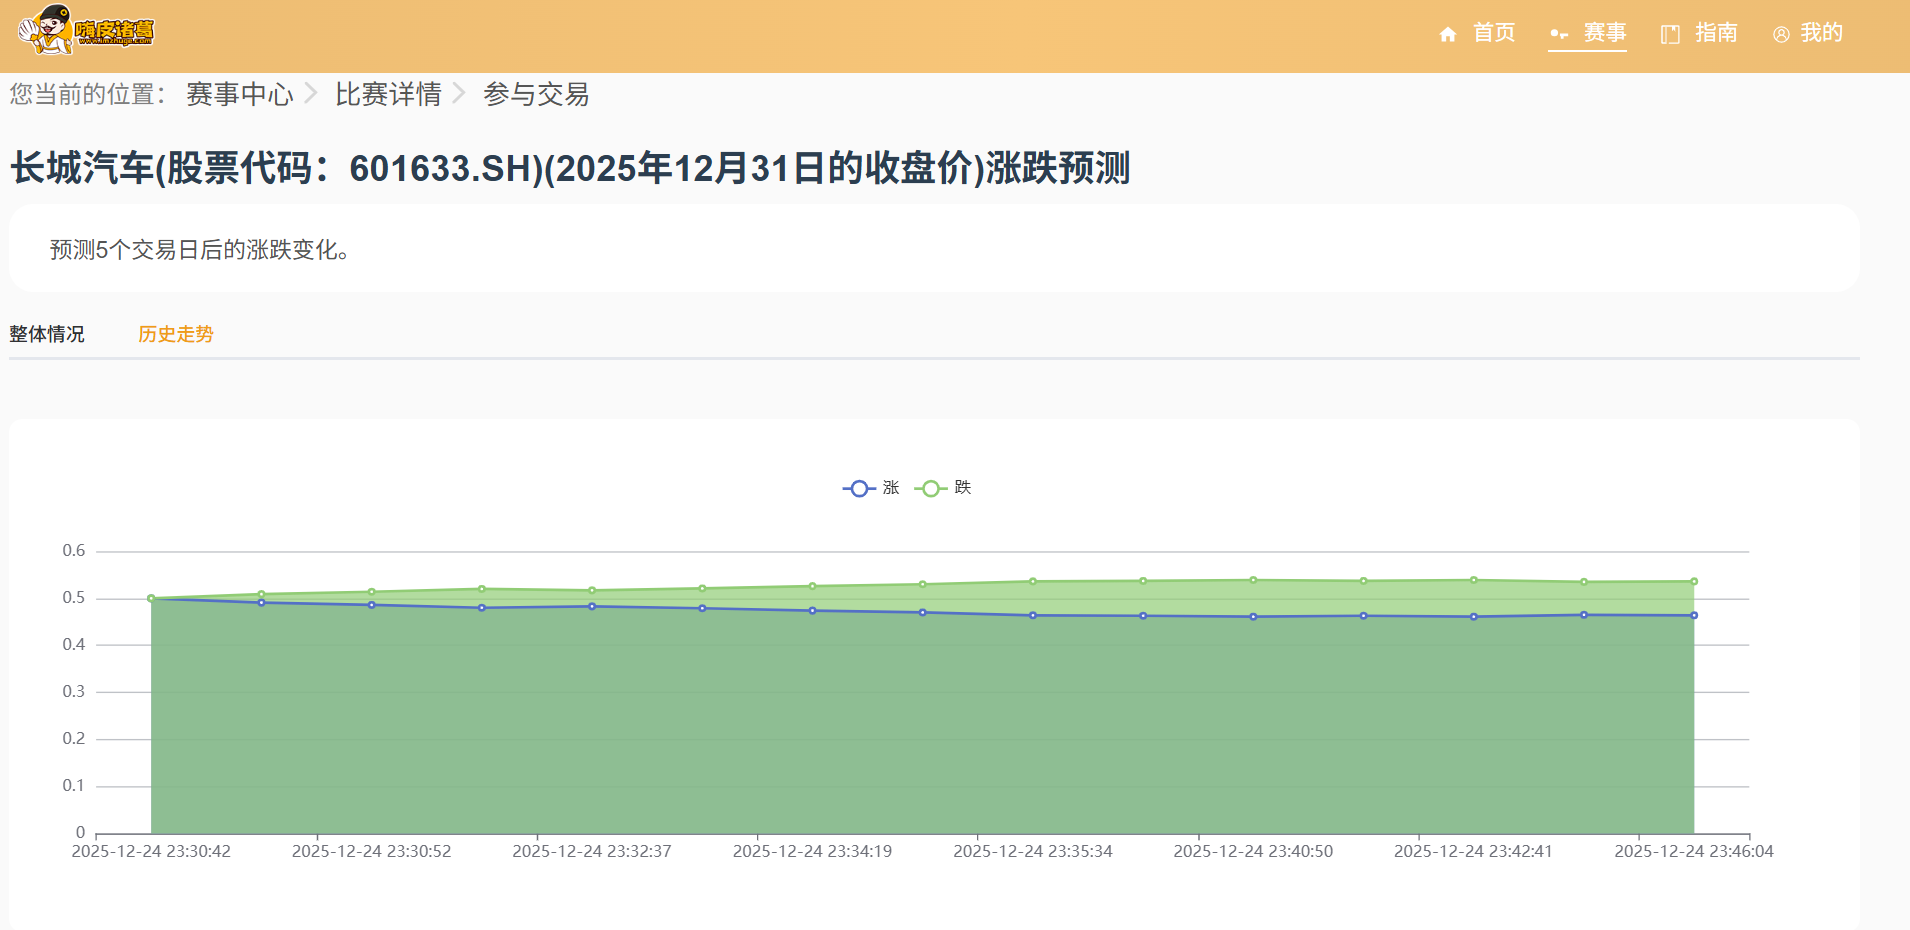

# 课程总结
数据分析核心流程：
- 数据获取
- 数据预处理
- 可视化与数据科学展示工具
- 模型构建与评估

课程特色与勉励：
- AI编程、大模型、智能体
- 文本分析
- 量化交易


# 期末愉快，开心、诚信地考试！
# 考试时穿上正装、适当化妆！